# New clustergram notebook

This notebook replicates the notebook [here](https://pdc.cancer.gov/API_documentation/PDC_clustergram.html), creating a clustergram with proteomics data from the PDC, but instead streaming data through the `cptac` package.

In [1]:
import cptac.pancan as pancan
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

First, download and load the CCRCC dataset from the PDC.

In [2]:
pancan.download("pdcccrcc")

The pdcccrcc dataset has been downloaded previously. If you wish to erase the existing download and re-download it, pass 'redownload=True'.


In [3]:
ccrcc = pancan.PdcCcrcc()

Then, get the clinical and proteome files.

In [4]:
clinical = ccrcc.get_clinical()
prot = ccrcc.get_proteomics()

Since the expression values are returned as strings, we need to convert those to floats and deal with missing data.

In [5]:
mask_na = 0.000666
prot = prot.fillna(mask_na)

We can then set up a color mapping function for the clinical annotations.

In [6]:
def get_colors(df, name, color) -> pd.Series:
    s = df[name]
    su = s.unique()
    colors = sns.light_palette(color, len(su))
    lut = dict(zip(su, colors))
    return s.map(lut)

Next, call get_colors() to map the tumor_stage and primary_diagnosis attributes.  Others are available.

In [7]:
clinical = clinical.join(prot, how="right").droplevel(0) # Only keep clinical data for samples in quant table
stage_col_colors = get_colors(clinical, 'tumor_stage', 'red')
diagnosis_col_colors = get_colors(clinical, 'primary_diagnosis', 'green')

And, finally, generate the large clustermap using seaborn.clustermap

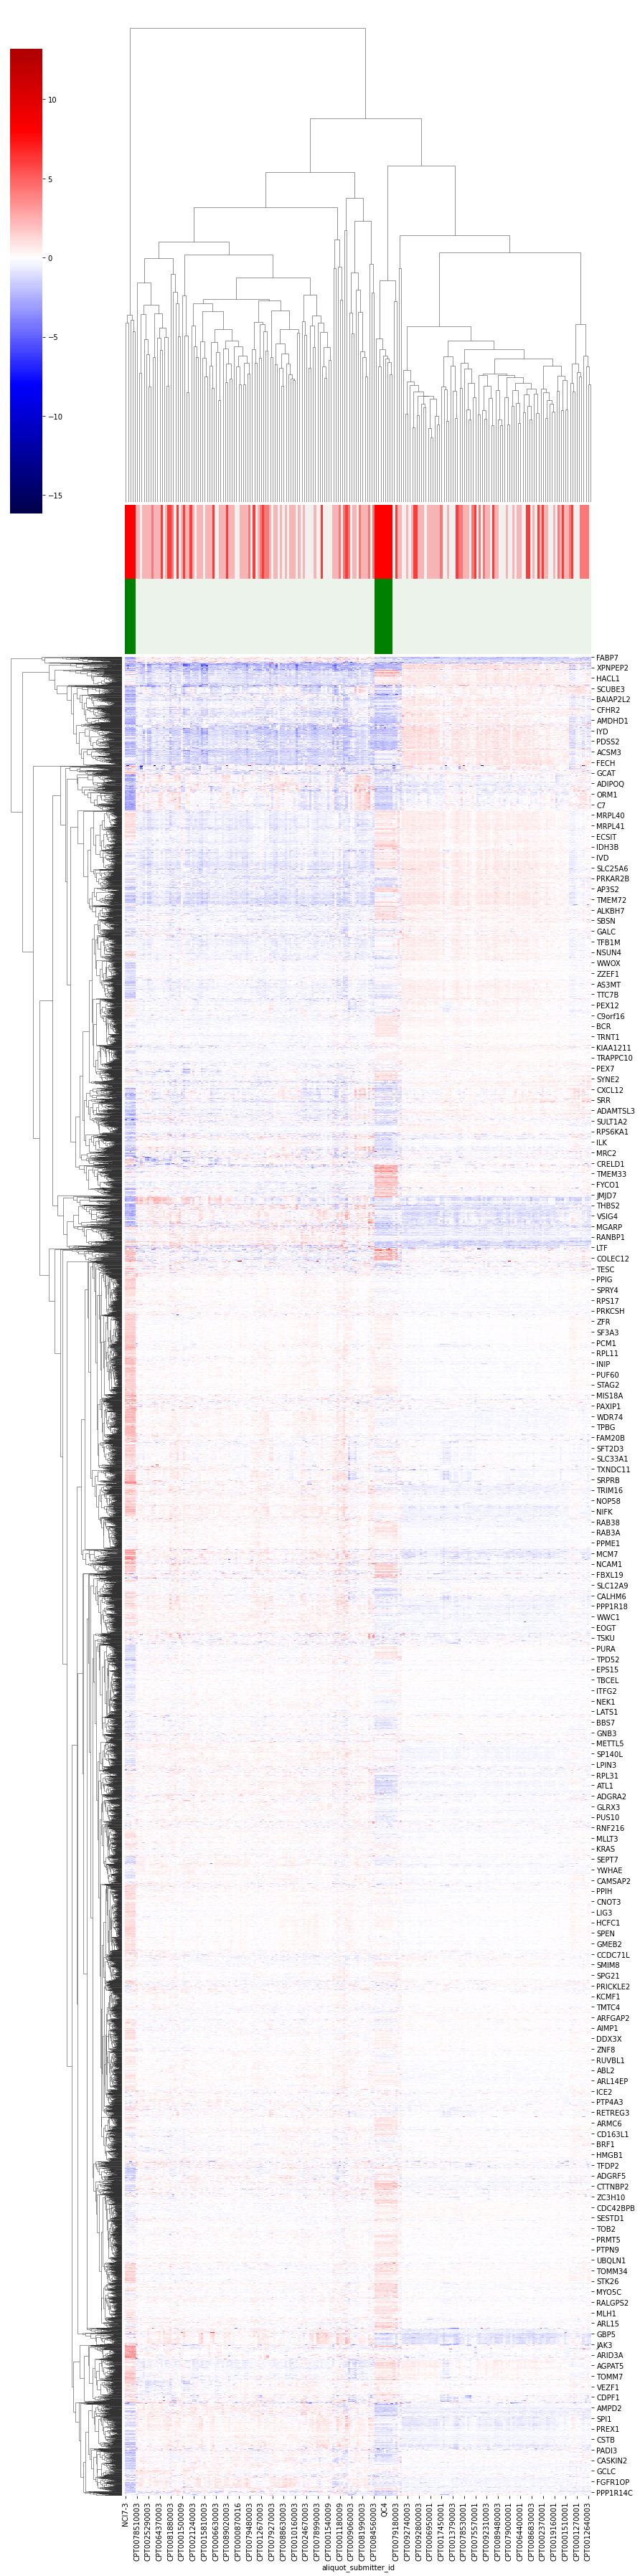

In [8]:
prot = prot.droplevel(0).transpose() # Get rid of extra index level, transpose table
sns.clustermap(prot, metric='euclidean', method='complete', cmap='seismic', mask=prot == mask_na, center=0.,
                figsize=(12.5, 50), col_colors=[stage_col_colors, diagnosis_col_colors])
plt.show()

You could also convert the log2 ratio data to a standard statistic, like z-score.
This can help compress the range, accounting for outliers.

In [9]:
zdf = prot.T.apply(zscore, ddof=len(prot.columns)-1)
zdf = zdf.T

And examine clustering according to that transformation.

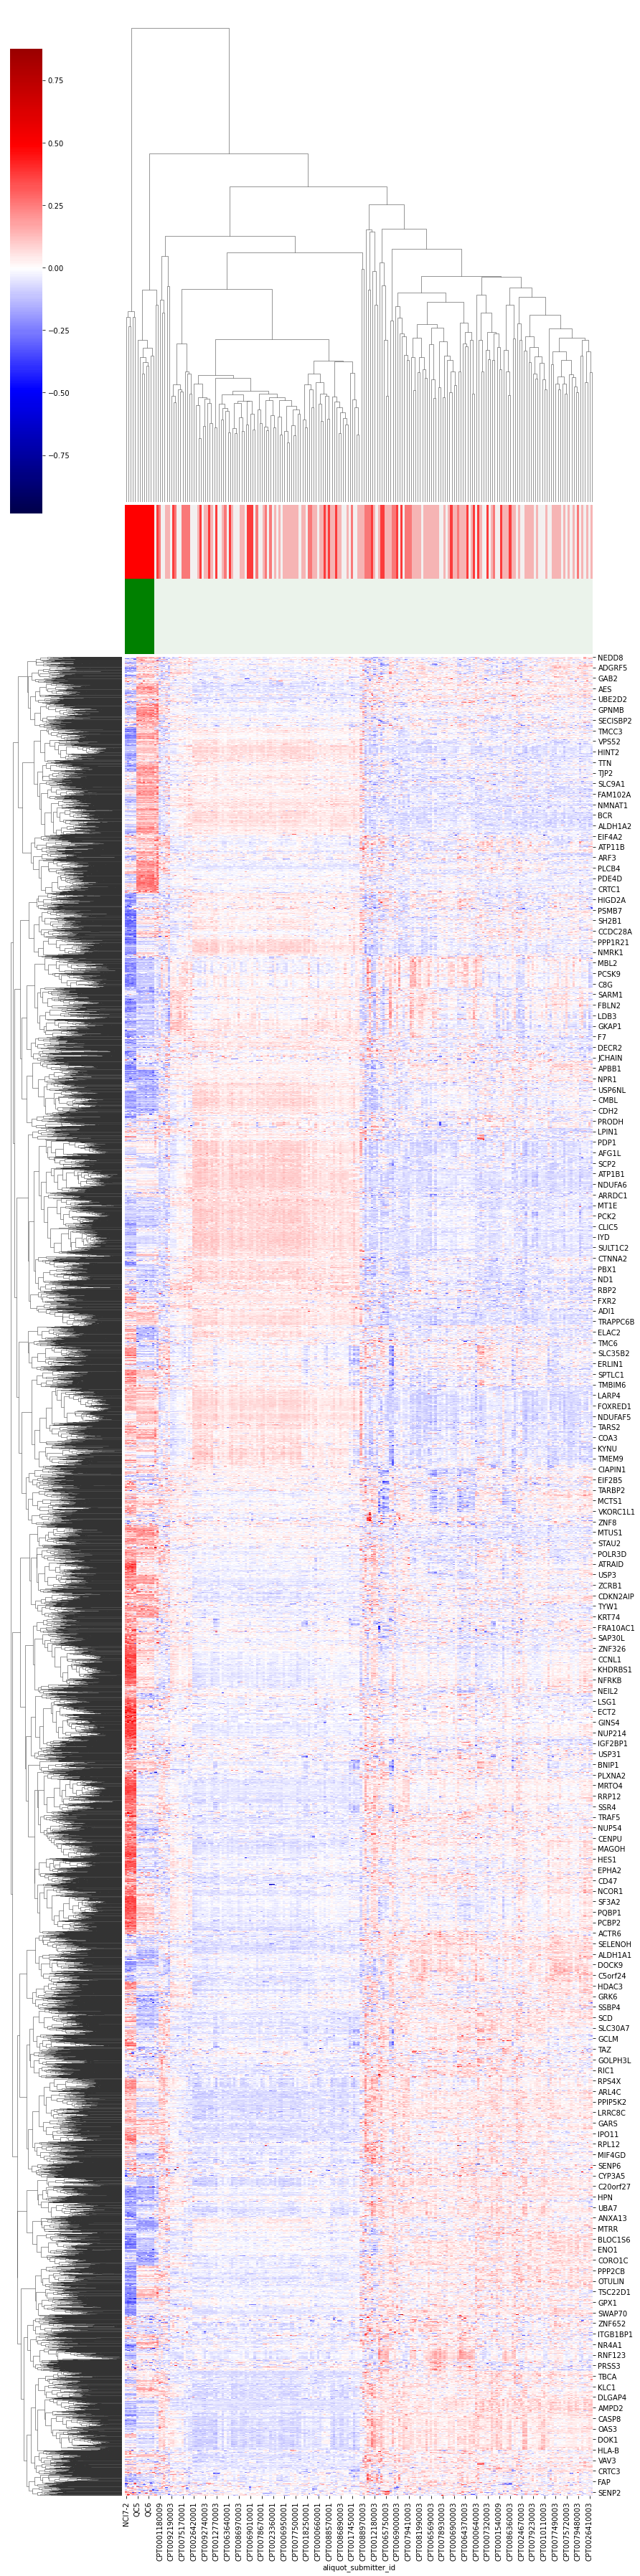

In [10]:
sns.clustermap(zdf, metric='euclidean', method='complete', cmap='seismic', mask=prot == mask_na, center=0.,
               col_colors=[stage_col_colors, diagnosis_col_colors], figsize=(12.5, 50))
plt.show()